# E-Commerce Customer Churn Prediction — XGBoost Model
**Author:** Meriem Aznag  
**Dataset:** Kaggle E-Commerce Customer Behavior Dataset (50,000 records)  
**Goal:** Predict which customers are likely to churn using XGBoost, 
and explain the predictions using SHAP values.

## Why XGBoost?
Logistic Regression draws a single linear boundary between churners 
and non-churners. XGBoost builds hundreds of decision trees 
sequentially — each one correcting the mistakes of the previous — 
making it far more powerful on real-world behavioral data.

## 1- Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ✓")

All libraries loaded ✓


## 1. Load & Inspect Data
50,000 customer records with 25 features covering behavioral, 
transactional, and engagement data. Target variable: `Churned` (1 = churned, 0 = retained).

In [14]:
import pandas as pd

df = pd.read_csv('data/ecommerce_customer_dataset.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['Churned'].value_counts())

(50000, 25)
Age                              float64
Gender                            object
Country                           object
City                              object
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                  float64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                            int64
Sign

In [15]:
df = pd.read_csv('data/ecommerce_customer_dataset.csv')  # your actual filename
print(f"Shape: {df.shape}")
print(f"\nChurn distribution:\n{df['Churned'].value_counts()}")
print(f"\nChurn rate: {df['Churned'].mean()*100:.1f}%")


Shape: (50000, 25)

Churn distribution:
Churned
0    35550
1    14450
Name: count, dtype: int64

Churn rate: 28.9%


## 2. Handle Missing Values
Several features have 5–12% missing values. We fill with the **median** 
(not mean) because the median is robust to outliers — 
a single extreme value won't distort the fill.

XGBoost can technically handle missing values natively, but explicit 
filling makes our pipeline cleaner and more transparent.

In [16]:
# Numerical columns — fill with median (robust to outliers)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols.remove('Churned')  # don't fill target

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled {col} with median: {median_val:.2f}")

print(f"\nMissing values remaining: {df.isnull().sum().sum()}")

Filled Age with median: 38.00
Filled Session_Duration_Avg with median: 26.80
Filled Pages_Per_Session with median: 8.40
Filled Wishlist_Items with median: 4.00
Filled Days_Since_Last_Purchase with median: 21.00
Filled Discount_Usage_Rate with median: 40.20
Filled Returns_Rate with median: 5.40
Filled Email_Open_Rate with median: 19.70
Filled Customer_Service_Calls with median: 5.00
Filled Product_Reviews_Written with median: 2.00
Filled Social_Media_Engagement_Score with median: 27.60
Filled Mobile_App_Usage with median: 18.60
Filled Payment_Method_Diversity with median: 2.00
Filled Credit_Balance with median: 1896.00

Missing values remaining: 0


## 3. Encode Categorical Features
Machine learning models require numerical input. We use **Label Encoding** 
to convert categorical columns (Gender, Country, City, Signup_Quarter) 
into integers. For tree-based models like XGBoost, label encoding is 
sufficient — unlike linear models, trees don't assume ordinal relationships.

In [17]:
categorical_cols = ['Gender', 'Country', 'City', 'Signup_Quarter']
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"Encoded: {col}")

print("\nEncoding done ✓")

Encoded: Gender
Encoded: Country
Encoded: City
Encoded: Signup_Quarter

Encoding done ✓


## 4. Train / Test Split
We split 80/20 with `stratify=y` — this ensures the churn rate (28.9%) 
is identical in both train and test sets. Without stratification, 
random splits on imbalanced data can produce misleading evaluation results.

In [18]:
X = df.drop('Churned', axis=1)
y = df['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y           # keeps churn ratio same in both splits
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"Churn rate in train: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test:  {y_test.mean()*100:.1f}%")

Train size: (40000, 24)
Test size:  (10000, 24)
Churn rate in train: 28.9%
Churn rate in test:  28.9%


## 5. Train XGBoost Model

### Handling Class Imbalance
Our dataset has 71% retained vs 29% churned — imbalanced but not extreme. 
We use `scale_pos_weight = negatives/positives ≈ 2.46` to tell the model 
to pay more attention to the minority class (churners).

### Early Stopping
We set `early_stopping_rounds=20` — training stops automatically 
when validation AUC stops improving. This prevents overfitting 
without manual tuning of `n_estimators`.

In [19]:
# scale_pos_weight handles class imbalance
# formula: number of negatives / number of positives
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.2f}")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50  # prints every 50 rounds
)

print("\nModel trained ✓")


scale_pos_weight: 2.46
[0]	validation_0-auc:0.85670
[50]	validation_0-auc:0.92782
[100]	validation_0-auc:0.92846
[113]	validation_0-auc:0.92857

Model trained ✓


## 6. Model Evaluation

We evaluate using four metrics:
- **ROC-AUC** — overall ability to rank churners above non-churners
- **Precision** — of predicted churners, how many actually churned
- **Recall** — of actual churners, how many did we catch
- **F1-Score** — harmonic mean of precision and recall

For a churn use case, **Recall is the most business-critical metric** — 
missing a churner means losing a customer. We accept slightly lower 
precision (sending retention offers to non-churners) to maximize recall.

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Retained       0.94      0.93      0.94      7110
     Churned       0.83      0.86      0.84      2890

    accuracy                           0.91     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.91      0.91      0.91     10000


ROC-AUC Score: 0.9287


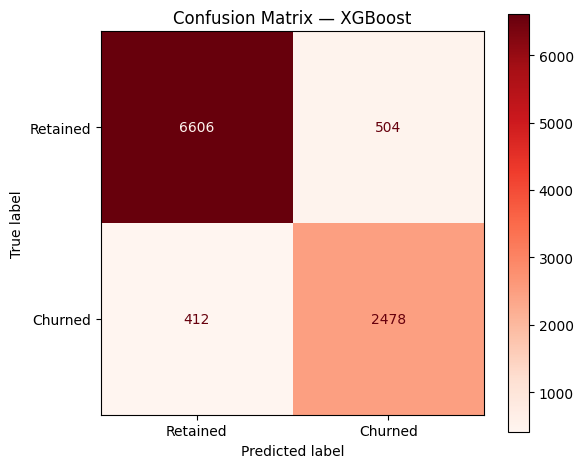

In [20]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, 
                                         display_labels=['Retained', 'Churned'],
                                         ax=ax, cmap='Reds')
plt.title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.savefig('images/confusion_matrix_xgb.png', dpi=150)
plt.show()

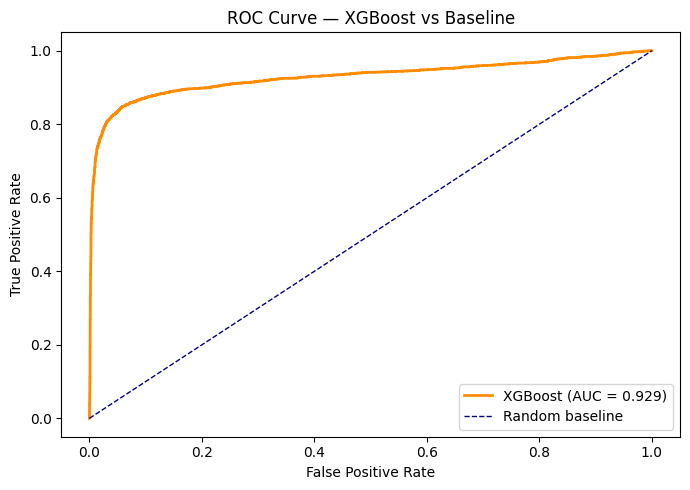

In [21]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XGBoost vs Baseline')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('images/roc_curve_xgb.png', dpi=150)
plt.show()

## 7. Model Explainability — SHAP Values

Accuracy alone is not enough. A business needs to know *why* 
the model flags a customer as high risk.

SHAP (SHapley Additive exPlanations) assigns each feature a value 
representing its contribution to each individual prediction:
- **Positive SHAP value** → pushes toward churn prediction
- **Negative SHAP value** → pushes toward retained prediction
- **Magnitude** → how strong the influence is

This transforms our model from a black box into an explainable tool 
that a business team can act on.

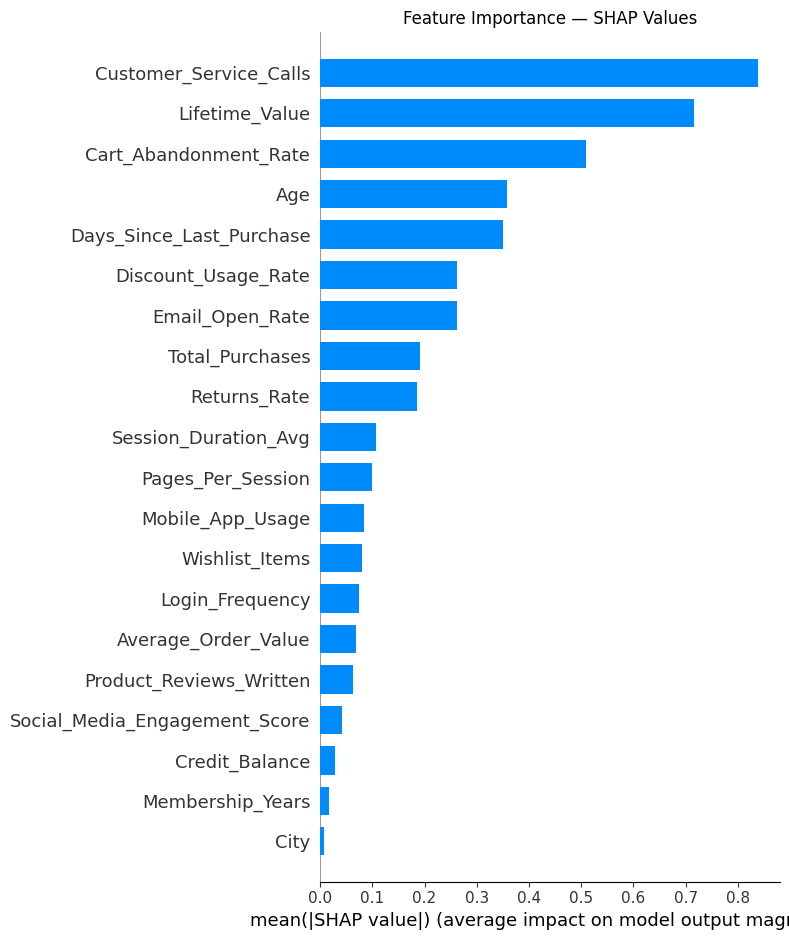

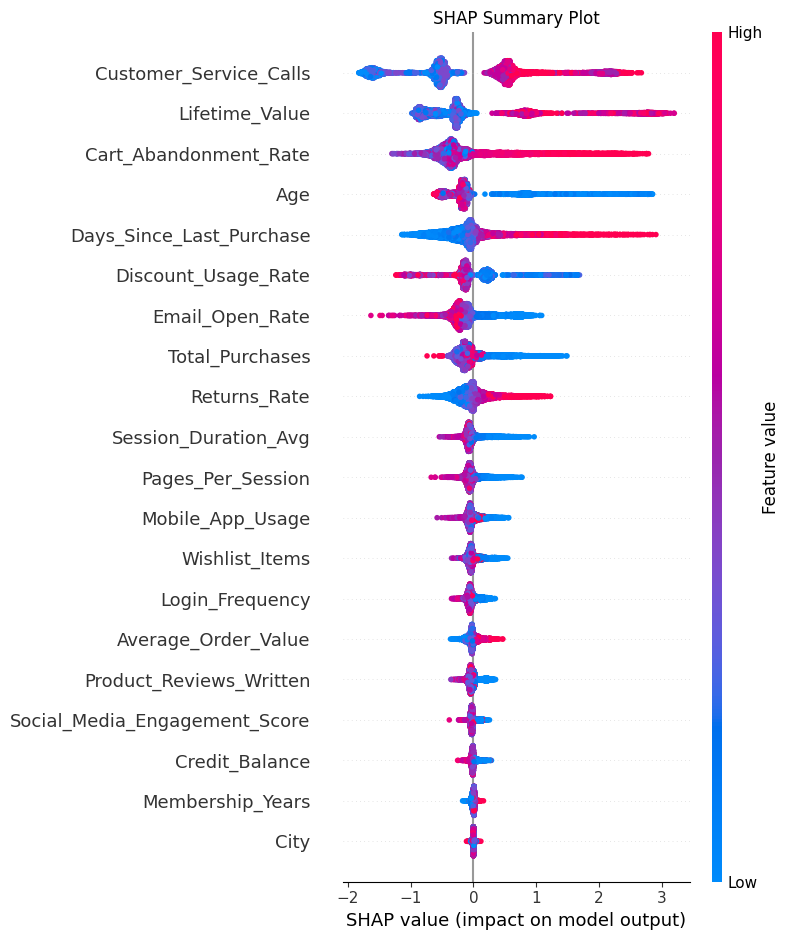

In [22]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global feature importance
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('Feature Importance — SHAP Values')
plt.tight_layout()
plt.savefig('images/shap_importance.png', dpi=150)
plt.show()

# Detailed SHAP plot (shows direction of impact)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.savefig('images/shap_summary.png', dpi=150)
plt.show()

## 8. Save Model
We serialize the trained model using `joblib`. This `.pkl` file 
is the deployable artifact — it can be loaded by a FastAPI endpoint 
or Streamlit app to make real-time predictions without retraining.

In [23]:
import joblib
joblib.dump(model, 'churn_model_xgb.pkl')
print("Model saved as churn_model_xgb.pkl ✓")


Model saved as churn_model_xgb.pkl ✓


In [24]:
# ============================================================
# CONCLUSIONS & BUSINESS RECOMMENDATIONS
# ============================================================

"""
MODEL SUMMARY
─────────────────────────────────────────
Algorithm      : XGBoost (Gradient Boosting)
ROC-AUC        : 0.9287
Accuracy       : 91.0%
Churn Recall   : 86%
Training size  : 40,000 customers
Test size      : 10,000 customers

IMPROVEMENT OVER BASELINE
─────────────────────────────────────────
Logistic Regression AUC : 0.745
XGBoost AUC             : 0.929
Improvement             : +18.4 points

TOP CHURN DRIVERS (from SHAP)
─────────────────────────────────────────
1. Customer_Service_Calls   → High calls = high churn risk
2. Lifetime_Value           → High-value customers churning most
3. Cart_Abandonment_Rate    → Checkout friction driving exits
4. Days_Since_Last_Purchase → Inactivity is a strong signal
5. Email_Open_Rate          → Silent disengagement before churn

BUSINESS RECOMMENDATIONS
─────────────────────────────────────────
1. Build a weekly churn risk dashboard — score all customers
2. Trigger retention campaigns for anyone with risk score > 0.7
3. Prioritize high Lifetime_Value churners — highest ROI
4. Monitor Customer_Service_Calls as your earliest warning signal
5. Automate re-engagement emails for 30+ day inactive customers
6. Fix checkout UX to reduce Cart_Abandonment_Rate
"""

print("Project complete ✓")

Project complete ✓


## Results Summary

| Metric | Logistic Regression (baseline) | XGBoost (final) |
|---|---|---|
| ROC-AUC | 0.745 | **0.929** |
| Accuracy | 67.4% | **91.0%** |
| Churn Recall | 70% | **86%** |

## Key Findings

1. **Customer Service Calls** is the #1 churn predictor — frustrated customers leave
2. **High Lifetime Value customers** are churning most — highest priority for retention
3. **Cart Abandonment Rate** signals checkout friction
4. **Days Since Last Purchase** — inactivity is a strong leading indicator
5. **Email Open Rate** — customers stop opening emails before they churn

## Business Recommendations

| Action | Trigger | Expected Impact |
|---|---|---|
| VIP retention campaign | High LTV + risk score > 0.7 | Save highest-value customers |
| Re-engagement email | No purchase in 30+ days | Reactivate dormant customers |
| Checkout UX review | High cart abandonment segment | Reduce friction-driven churn |
| Support team alert | Customer service calls spike | Intervene before frustration peaks |
| Email re-engagement | Email open rate drops below 10% | Catch silent disengagement early |

## Next Steps
- Deploy as Streamlit web app
- Build FastAPI endpoint for real-time scoring  
- Experiment with hyperparameter tuning (Optuna)
- Add cross-validation for more robust evaluation